# In this notebook
I demonstrate a simple example of how to pull ERA5-Land data, and create a simple visualization of the resulting dataset.

In [1]:
import cdsapi

dataset = "reanalysis-era5-land"
request = {
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind"
    ],
    "year": "2023",
    "month": "07",
    "day": [
        "01",
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "grib",
    "download_format": "unarchived",
    "area": [36.3, -79.1, 35.8, -78.6]
}

target = "../data/ERA5/2023_07_01.grib"
client = cdsapi.Client()
client.retrieve(dataset, request, target)#.download()

2025-03-24 16:40:15,768 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-03-24 16:40:15,769 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-03-24 16:40:16,138 INFO Request ID is 1836e04b-41fb-4aea-9e9e-79a4eff17980
2025-03-24 16:40:16,321 INFO status has been updated to accepted
2025-03-24 16:40:25,218 INFO status has been updated to running
2025-03-24 16:40:49,847 INFO status has been updated to successful


'../data/ERA5/2023_07_01.grib'

So, we need to make $12 \times 6 = 72$ calls to retrieve this data. If it takes roughly 6 minutes per call, then it will take roughly 7 hours to pull all of this data.

In [15]:
[f"{month:02d}" for month in range(1, 13)]

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']

In [1]:
import xarray as xr

# Open the GRIB file
dataset = xr.open_dataset("../test/2019-01.grib", engine="cfgrib")

# Print the dataset to inspect its contents
print(dataset)

# Access specific variables, for example:
temperature = dataset["t2m"]

# Perform operations on the data, for example:
mean_temperature = temperature.mean()
print(mean_temperature.values)

<xarray.Dataset> Size: 375kB
Dimensions:     (time: 32, step: 24, latitude: 5, longitude: 6)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 256B 2018-12-31 2019-01-01 ... 2019-01-31
  * step        (step) timedelta64[ns] 192B 01:00:00 ... 1 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 40B 36.15 36.05 35.95 35.85 35.75
  * longitude   (longitude) float64 48B -79.05 -78.95 -78.85 ... -78.65 -78.55
    valid_time  (time, step) datetime64[ns] 6kB ...
Data variables:
    d2m         (time, step, latitude, longitude) float32 92kB ...
    t2m         (time, step, latitude, longitude) float32 92kB ...
    u10         (time, step, latitude, longitude) float32 92kB ...
    v10         (time, step, latitude, longitude) float32 92kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conve

/Users/zdc6/mambaforge/envs/mumbai-data/lib/python3.13/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [12]:
# Select the data athe first time step

temperature_at_t0 = temperature.isel(time=2, step=1)
print(temperature_at_t0.values)


[[285.75903 285.8871  285.99835 286.10095 286.222   286.30896]
 [286.13513 286.08337 286.19476 286.43976 286.5609  286.67316]
 [286.59894 286.54724 286.57068 286.8158  286.91632 287.0287 ]
 [287.0609  287.1341  287.1576  287.2005  287.30115 287.45044]
 [287.50714 287.58038 287.60773 287.65076 287.76398 287.9135 ]]


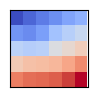

In [21]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(1, 1))
temperature_at_t0.plot(cmap='coolwarm', ax=ax)
# remove axis labels
ax.set_ylabel('')
ax.set_xlabel('')
# Remove colorbar
ax.collections[0].colorbar.remove()
# remove title
plt.title('')
# remove ticks
ax.set_xticks([])
ax.set_yticks([])
# ax.set_title('2m Temperature at First Time Step')
# Save the plot
plt.savefig("../final_fig/era5.pdf", bbox_inches='tight')